In [102]:
# Run this part if you want to mount your Google Drive to Colab VM and
# work on your lab folder directly. Make sure to enter the correct path to your
# folder. Otherwise, you can work on the realtime workspace but you will need
# to upload your images.

from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# lab folder, e.g. 'Colab Notebooks/ENEL503/Lab5'
FOLDERNAME = 'Colab Notebooks/ENEL503/FinalProject' #None
assert FOLDERNAME is not None, "[!] Enter the foldername."
FullPath = '/content/drive/MyDrive/' + FOLDERNAME
print(FullPath)

import os
os.chdir(FullPath)
!pwd # check that your folder is the current working directory

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append(FullPath)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/ENEL503/FinalProject
/content/drive/MyDrive/Colab Notebooks/ENEL503/FinalProject


Imports

In [103]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

Settings

In [104]:
IMG_SIZE = 32
BATCH_SIZE = 64
NUM_CLASSES = 43
NUM_EPOCHS = 5
LEARNING_RATE = 0.001
SEED = 42

#training subset
USE_SUBSET = True   # True = fast dev, False = full training
SUBSET_SIZE = 10000
#testing subset
USE_TEST_SUBSET = True
TEST_SUBSET_SIZE = 2000

torch.manual_seed(SEED)
np.random.seed(SEED)

Dataset paths

In [105]:
train_root = os.path.join(FullPath, "GTSRB", "Final_Training", "Images")
test_images_dir = os.path.join(FullPath, "GTSRB", "Final_Test", "Images")
test_csv = os.path.join(FullPath, "GTSRB", "GT-final_test.csv")

print("Train root:", train_root)
print("Test images:", test_images_dir)
print("Test CSV:", test_csv)

Train root: /content/drive/MyDrive/Colab Notebooks/ENEL503/FinalProject/GTSRB/Final_Training/Images
Test images: /content/drive/MyDrive/Colab Notebooks/ENEL503/FinalProject/GTSRB/Final_Test/Images
Test CSV: /content/drive/MyDrive/Colab Notebooks/ENEL503/FinalProject/GTSRB/GT-final_test.csv


RGB preprocessing

In [106]:
class RGBPreprocess:
    def __init__(
        self,
        img_size=32,
        use_hist_eq=True,
        use_edges=True,
        use_morph=True,
        edge_blend_weight=0.2
    ):
        self.img_size = img_size
        self.use_hist_eq = use_hist_eq
        self.use_edges = use_edges
        self.use_morph = use_morph
        self.edge_blend_weight = edge_blend_weight

    def __call__(self, img):
        # PIL -> numpy RGB
        img = np.array(img.convert("RGB"))

        # Resize
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Histogram normalization on luminance channel
        if self.use_hist_eq:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l = clahe.apply(l)
            lab = cv2.merge((l, a, b))
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # Edge detection + morphology
        if self.use_edges:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            gray = cv2.GaussianBlur(gray, (3, 3), 0)

            edges = cv2.Canny(gray, 100, 200)

            if self.use_morph:
                kernel = np.ones((3, 3), np.uint8)
                edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

            edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

            # Blend edge map into RGB image
            img = cv2.addWeighted(img, 1.0, edges_rgb, self.edge_blend_weight, 0)

        # Convert to float tensor and normalize to [-1, 1]
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))   # HWC -> CHW
        img = (img - 0.5) / 0.5

        return torch.tensor(img, dtype=torch.float32)

resize only + normalize

In [107]:
class BaselineRGBTransform:
    def __init__(self, img_size=32):
        self.img_size = img_size

    def __call__(self, img):
        img = np.array(img.convert("RGB"))
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        img = (img - 0.5) / 0.5
        return torch.tensor(img, dtype=torch.float32)

Choose transform

In [108]:
train_transform = RGBPreprocess(
    img_size=IMG_SIZE,
    use_hist_eq=True,
    use_edges=True,
    use_morph=True,
    edge_blend_weight=0.2
)

test_transform = RGBPreprocess(
    img_size=IMG_SIZE,
    use_hist_eq=True,
    use_edges=True,
    use_morph=True,
    edge_blend_weight=0.2
)

# If you want a baseline later, replace with:
# train_transform = BaselineRGBTransform(img_size=IMG_SIZE)
# test_transform = BaselineRGBTransform(img_size=IMG_SIZE)


Custom training dataset

In [109]:
class GTSRBTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for class_name in sorted(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            # Only numeric class folders
            if not class_name.isdigit():
                continue

            class_id = int(class_name)

            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.ppm', '.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_dir, file_name)
                    self.samples.append((img_path, class_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

Custom test dataset

In [110]:
class GTSRBTestDataset(Dataset):
    def __init__(self, images_dir, csv_file, transform=None):
        self.images_dir = images_dir
        self.annotations = pd.read_csv(csv_file, sep=';')
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        idx = int(idx)
        row = self.annotations.iloc[idx]
        img_name = row['Filename']
        label = int(row['ClassId'])

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

Load datasets

In [111]:
full_train_dataset = GTSRBTrainDataset(train_root, transform=train_transform)

# Use subset for faster development
if USE_SUBSET:
    print(f"Using subset of {SUBSET_SIZE} images for development")
    indices = torch.randperm(len(full_train_dataset))[:SUBSET_SIZE]
    full_train_dataset = torch.utils.data.Subset(full_train_dataset, indices)

print("Number of training images:", len(full_train_dataset))

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

full_test_dataset = GTSRBTestDataset(test_images_dir, test_csv, transform=test_transform)

if USE_TEST_SUBSET:
    indices = torch.randperm(len(full_test_dataset))[:TEST_SUBSET_SIZE].tolist()
    test_dataset = torch.utils.data.Subset(full_test_dataset, indices)
else:
    test_dataset = full_test_dataset

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train split:", len(train_dataset))
print("Val split:", len(val_dataset))
print("Test set:", len(test_dataset))

Using subset of 10000 images for development
Number of training images: 10000
Train split: 8000
Val split: 2000
Test set: 2000


Visualize preprocessing

In [112]:
def show_preprocessing_pipeline(dataset, preprocess, num_images=3):
    plt.figure(figsize=(18, 4 * num_images))

    for row in range(num_images):
        if hasattr(dataset, "indices"):  # subset
          real_idx = dataset.indices[row]
          img_path, label = dataset.dataset.samples[real_idx]
        else:  # full dataset
            img_path, label = dataset.samples[row]
        img_path, label = dataset.dataset.samples[real_idx]
        img = Image.open(img_path).convert("RGB")

        original = np.array(img)
        resized = cv2.resize(original, (preprocess.img_size, preprocess.img_size))

        if preprocess.use_hist_eq:
            lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l_eq = clahe.apply(l)
            lab_eq = cv2.merge((l_eq, a, b))
            hist_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
        else:
            hist_eq = resized.copy()

        gray = cv2.cvtColor(hist_eq, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (3, 3), 0)
        edges = cv2.Canny(blurred, 100, 200)

        if preprocess.use_morph:
            kernel = np.ones((3, 3), np.uint8)
            morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
        else:
            morph = edges.copy()

        if preprocess.use_edges:
            edges_rgb = cv2.cvtColor(morph, cv2.COLOR_GRAY2RGB)
            blended = cv2.addWeighted(hist_eq, 1.0, edges_rgb, preprocess.edge_blend_weight, 0)
        else:
            blended = hist_eq.copy()

        titles = [
            f"Original\nClass {label}",
            "Resized",
            "Histogram Equalized",
            "Edges",
            "After Morphology",
            "Final (Blended)"
        ]

        images = [original, resized, hist_eq, edges, morph, blended]

        for col in range(len(images)):
            plt.subplot(num_images, len(images), row * len(images) + col + 1)

            if len(images[col].shape) == 2:
                plt.imshow(images[col], cmap="gray")
            else:
                plt.imshow(images[col])

            plt.title(titles[col], fontsize=10)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

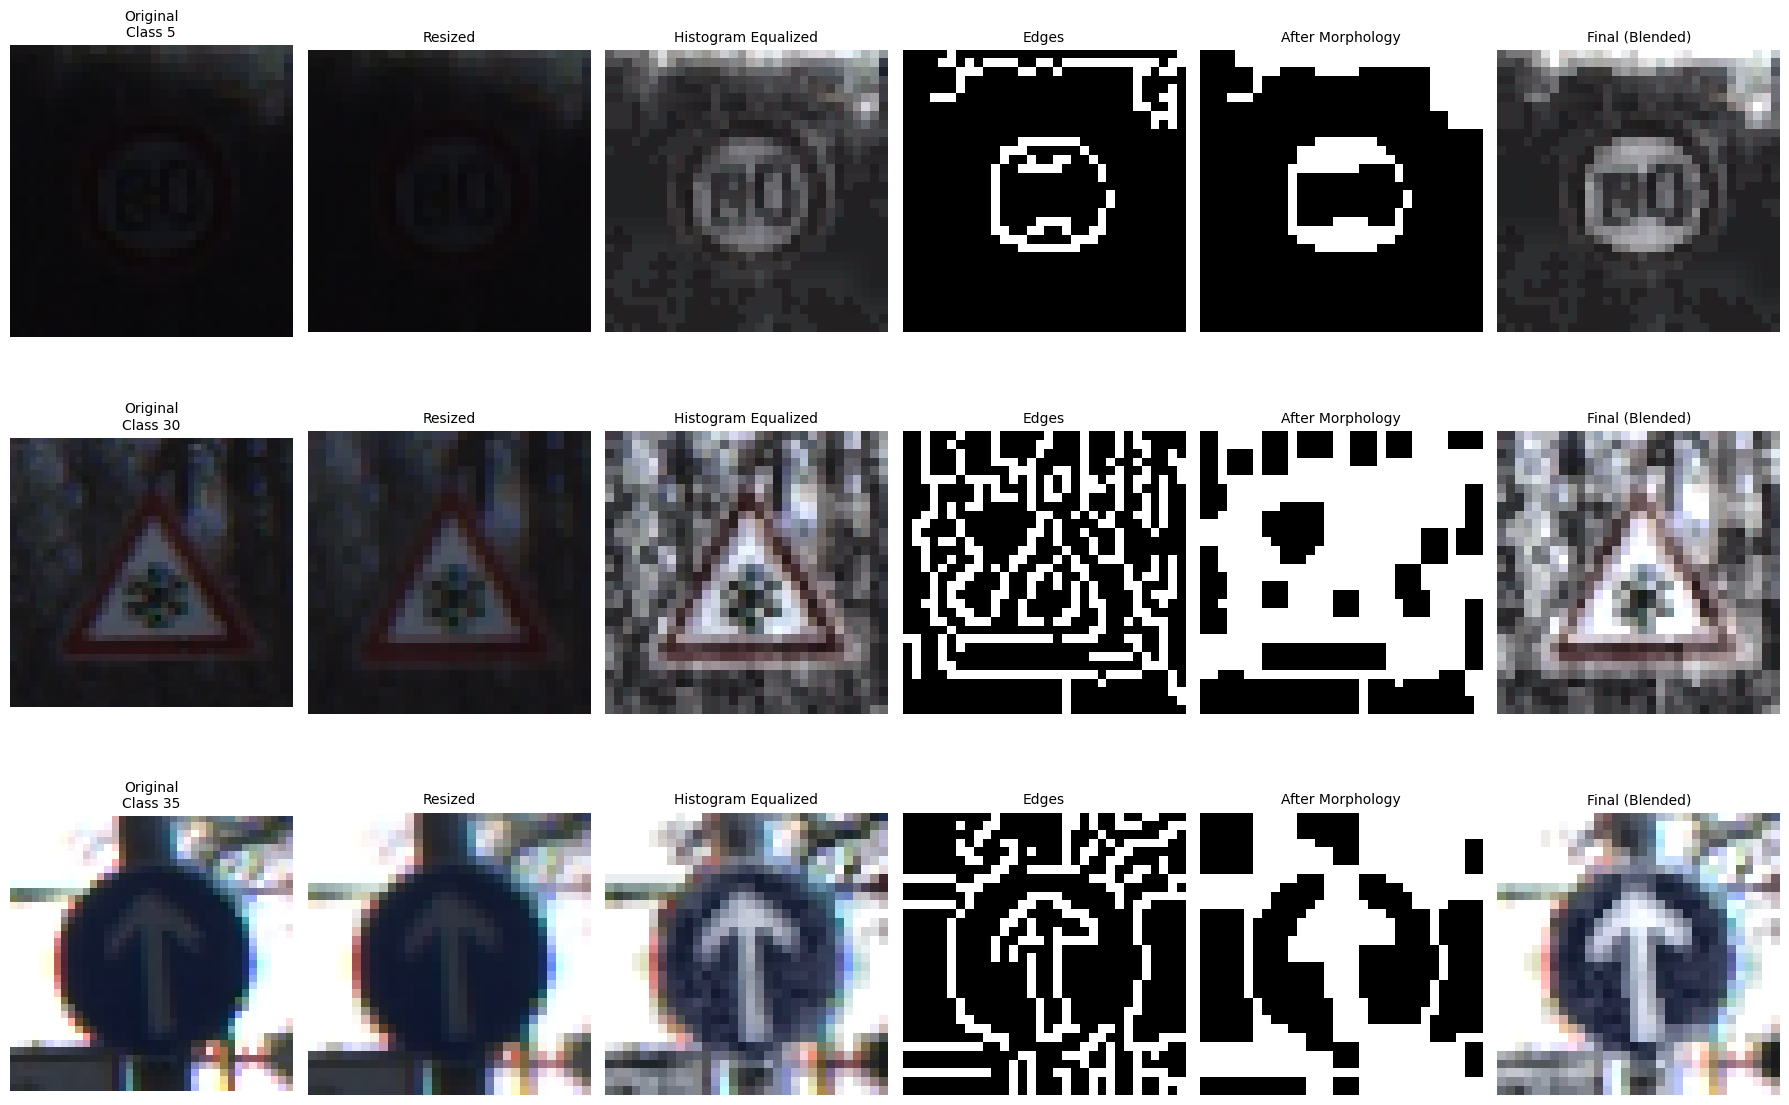

In [113]:
preprocess = RGBPreprocess(
    img_size=IMG_SIZE,
    use_hist_eq=True,
    use_edges=True,
    use_morph=True,
    edge_blend_weight=0.2
)

show_preprocessing_pipeline(full_train_dataset, preprocess, num_images=3)

CNN model

In [114]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Training setup

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = TrafficSignCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Using device: cuda


Train / evaluate functions

In [116]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

Training loop

In [117]:
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_gtsrb_cnn.pth")

print("Best validation accuracy:", best_val_acc)

Epoch 1/5
Train Loss: 1.6500, Train Acc: 54.14%
Val   Loss: 0.4654, Val   Acc: 89.25%
----------------------------------------
Epoch 2/5
Train Loss: 0.3246, Train Acc: 90.78%
Val   Loss: 0.1557, Val   Acc: 95.80%
----------------------------------------
Epoch 3/5
Train Loss: 0.1178, Train Acc: 96.56%
Val   Loss: 0.1021, Val   Acc: 96.75%
----------------------------------------
Epoch 4/5
Train Loss: 0.0679, Train Acc: 97.95%
Val   Loss: 0.0894, Val   Acc: 97.40%
----------------------------------------
Epoch 5/5
Train Loss: 0.0403, Train Acc: 98.86%
Val   Loss: 0.1208, Val   Acc: 96.20%
----------------------------------------
Best validation accuracy: 97.4


Load best model

In [118]:
model.load_state_dict(torch.load("best_gtsrb_cnn.pth"))

<All keys matched successfully>

Final testing

In [119]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.1994
Test Accuracy: 93.55%


Classification report

In [120]:

print(classification_report(y_true, y_pred, digits=4))


              precision    recall  f1-score   support

           0     1.0000    0.7500    0.8571         8
           1     1.0000    0.9386    0.9683       114
           2     0.8992    0.9748    0.9355       119
           3     0.9176    0.9176    0.9176        85
           4     0.9417    0.9576    0.9496       118
           5     0.8218    0.8737    0.8469        95
           6     1.0000    0.7826    0.8780        23
           7     0.9848    0.8784    0.9286        74
           8     0.9103    0.9861    0.9467        72
           9     0.9863    0.9730    0.9796        74
          10     0.9884    0.9341    0.9605        91
          11     0.8906    0.9661    0.9268        59
          12     1.0000    0.9712    0.9854       104
          13     0.9675    0.9835    0.9754       121
          14     1.0000    1.0000    1.0000        45
          15     0.9459    1.0000    0.9722        35
          16     1.0000    0.9444    0.9714        18
          17     1.0000    

Confusion matrix

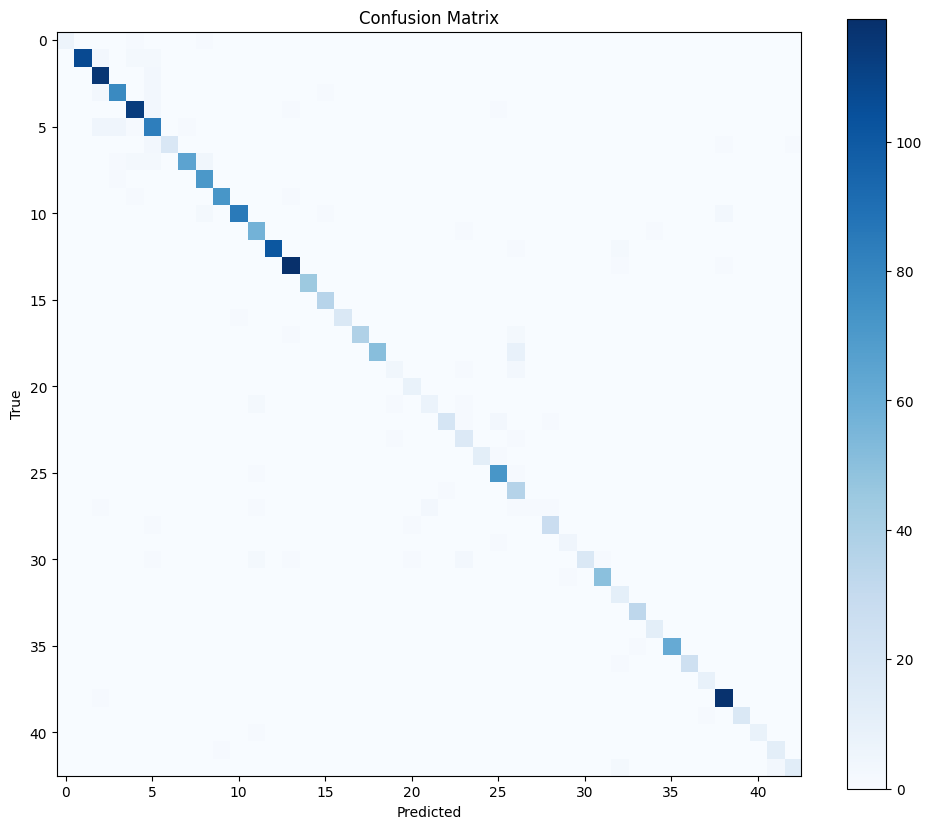

In [121]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()